In [3]:
import numpy as np
import scipy.signal as sig

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import scipy.signal as sig
from scipy.io.wavfile import write
import wave
import struct
from IPython.display import display, Audio


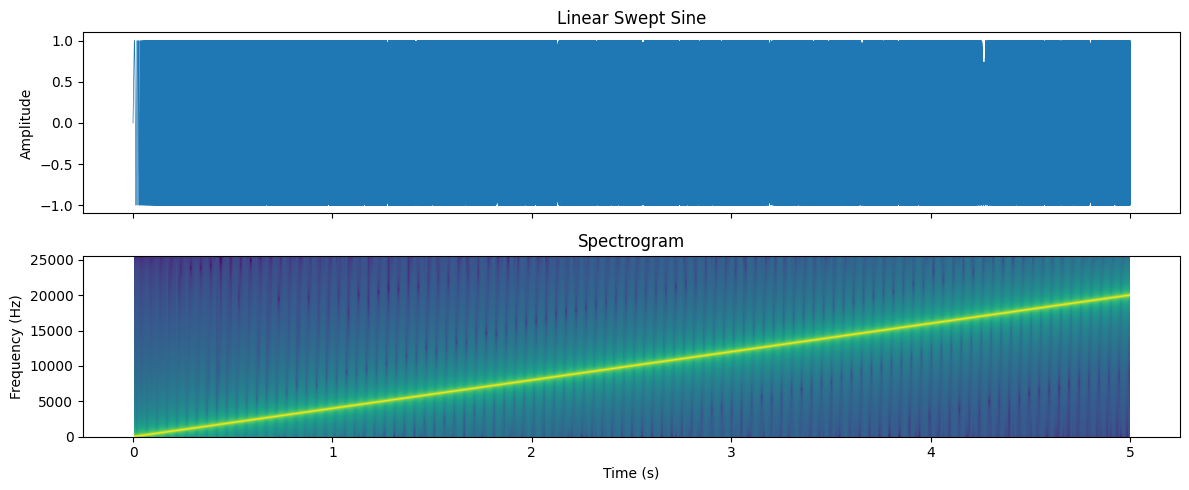

In [4]:

# --- Linear Swept Sine (Linear Chirp) ---

fe = 51200          # sampling frequency (Hz)
T  = 5.0            # duration (s)
f1 = 20.0           # start frequency (Hz)
f2 = 20000.0        # stop frequency (Hz)

t = np.arange(0, T, 1/fe)

# Linear swept sine: instantaneous frequency increases linearly from f1 to f2
k = (f2 - f1) / T   # sweep rate (Hz/s)
swept_sine = np.sin(2 * np.pi * (f1 * t + 0.5 * k * t**2))

# Inverse filter: time-reversed swept sine (works for linear sweeps)
inverse_filter = swept_sine[::-1]

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(t, swept_sine, lw=0.5)
axes[0].set_title("Linear Swept Sine")
axes[0].set_ylabel("Amplitude")
axes[1].specgram(swept_sine, Fs=fe, NFFT=1024, noverlap=512)
axes[1].set_title("Spectrogram")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Frequency (Hz)")
plt.tight_layout()
plt.show()

display(Audio(swept_sine, rate=fe))
